# Digit Recognizer Classification

## Reference workflow

This notebook classifies handwritten digits from pixel intensities. It inspects label balance and pixel distributions, creates train/test splits, then compares the shared classifiers. Run cells in order; experiment reports, charts, and metrics are saved in `../Results/`.

In [1]:
# Import the data, plotting, and numerical tools used throughout the analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Each row contains a digit label followed by its grayscale pixel values.
df = pd.read_csv("../Data/digit_recognizer.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(42000, 785)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [5]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [6]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=785)

In [7]:
missing_value_counts = df.isnull().sum()
missing_value_counts

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [8]:
print(df.duplicated().sum())

0


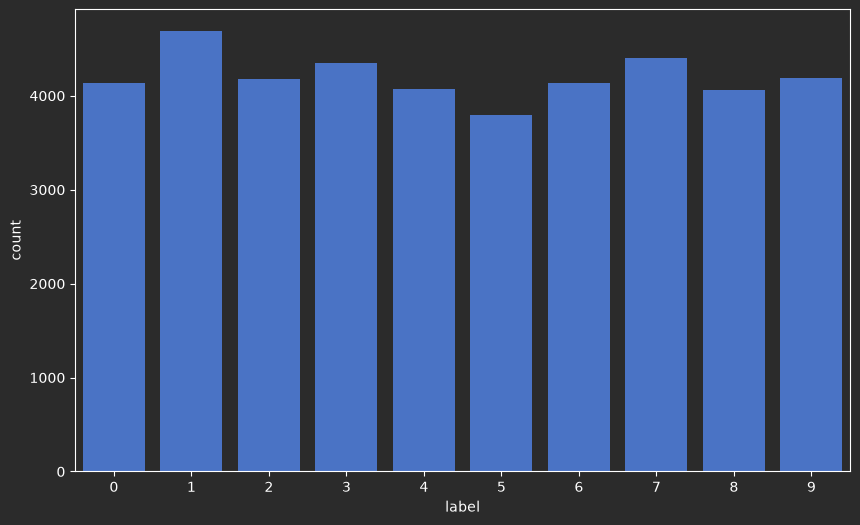

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(x = 'label', data = df)
plt.show()

In [10]:
# Separate the class label from the 784 pixel-intensity features.
X = df.drop("label", axis=1)
Y = df["label"]

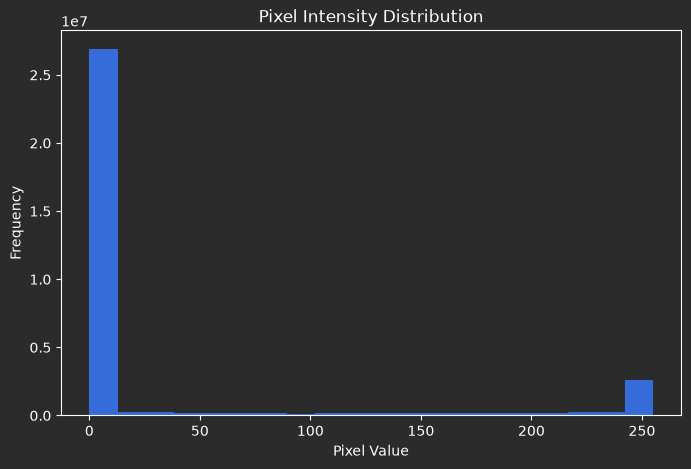

In [11]:
plt.figure(figsize=(8,5))

plt.hist(X.values.flatten(), bins=20)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

In [12]:
from utils.preprocessing import split_data, scale_data

# Stratified splitting preserves digit frequencies; scale only from training data.
X_train, X_test, Y_train, Y_test = split_data(X, Y)

X_train_scaled, X_test_scaled = scale_data(
    X_train,
    X_test
)

Saving confusion matrix to: ../Results/confusion_matrices\Digit_Recognizer_logistic_regression.png


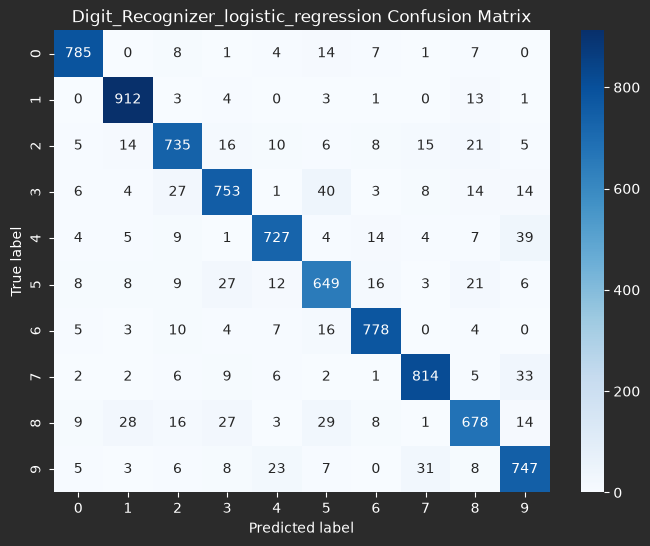


Classification Report - logistic_regression
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       827
           1       0.93      0.97      0.95       937
           2       0.89      0.88      0.88       835
           3       0.89      0.87      0.88       870
           4       0.92      0.89      0.90       814
           5       0.84      0.86      0.85       759
           6       0.93      0.94      0.94       827
           7       0.93      0.93      0.93       880
           8       0.87      0.83      0.85       813
           9       0.87      0.89      0.88       838

    accuracy                           0.90      8400
   macro avg       0.90      0.90      0.90      8400
weighted avg       0.90      0.90      0.90      8400

Saving JSON to: ../Results/Digit_Recognizer_logistic_regression_20260814_173918.json

Model: logistic_regression
{'accuracy': 0.9021428571428571, 'precision': 0.9019817676778713, 'recall': 0.90214

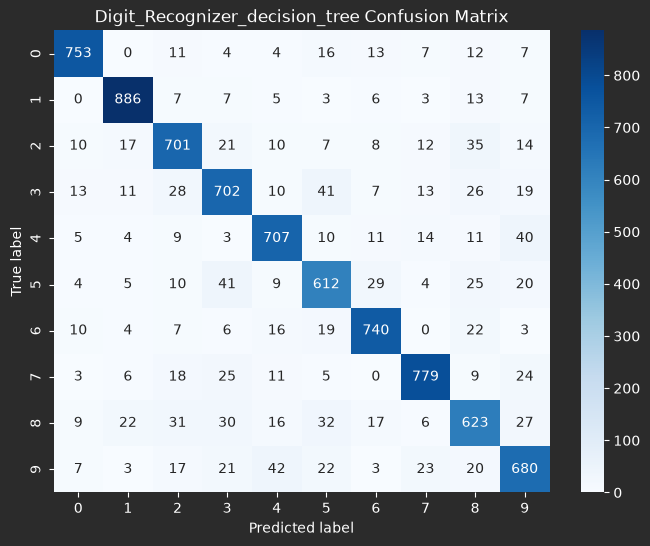


Classification Report - decision_tree
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       827
           1       0.92      0.95      0.94       937
           2       0.84      0.84      0.84       835
           3       0.82      0.81      0.81       870
           4       0.85      0.87      0.86       814
           5       0.80      0.81      0.80       759
           6       0.89      0.89      0.89       827
           7       0.90      0.89      0.89       880
           8       0.78      0.77      0.77       813
           9       0.81      0.81      0.81       838

    accuracy                           0.86      8400
   macro avg       0.85      0.85      0.85      8400
weighted avg       0.86      0.86      0.86      8400

Saving JSON to: ../Results/Digit_Recognizer_decision_tree_20260814_173928.json

Model: decision_tree
{'accuracy': 0.8551190476190477, 'precision': 0.8550323349818262, 'recall': 0.8551190476190477, 'f1':

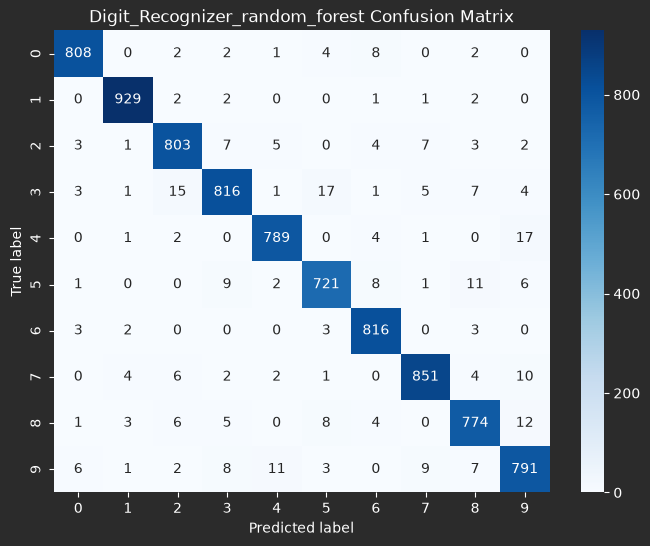


Classification Report - random_forest
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.99      0.99      0.99       937
           2       0.96      0.96      0.96       835
           3       0.96      0.94      0.95       870
           4       0.97      0.97      0.97       814
           5       0.95      0.95      0.95       759
           6       0.96      0.99      0.98       827
           7       0.97      0.97      0.97       880
           8       0.95      0.95      0.95       813
           9       0.94      0.94      0.94       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400

Saving JSON to: ../Results/Digit_Recognizer_random_forest_20260814_173946.json

Model: random_forest
{'accuracy': 0.964047619047619, 'precision': 0.9640445306810086, 'recall': 0.964047619047619, 'f1': 0

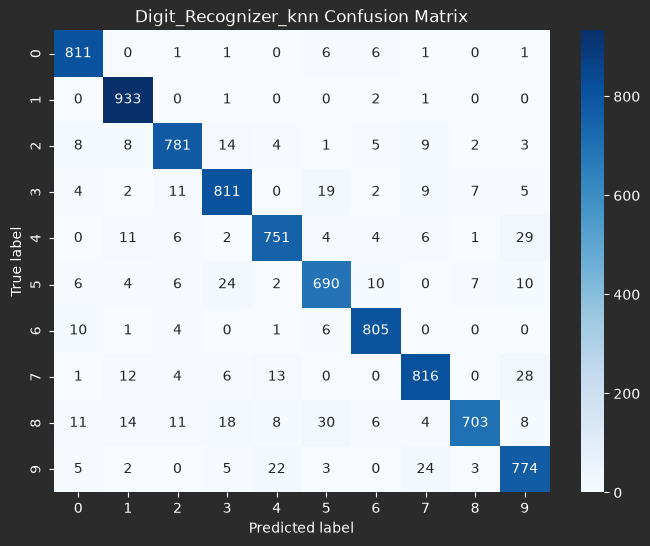


Classification Report - knn
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       827
           1       0.95      1.00      0.97       937
           2       0.95      0.94      0.94       835
           3       0.92      0.93      0.93       870
           4       0.94      0.92      0.93       814
           5       0.91      0.91      0.91       759
           6       0.96      0.97      0.97       827
           7       0.94      0.93      0.93       880
           8       0.97      0.86      0.92       813
           9       0.90      0.92      0.91       838

    accuracy                           0.94      8400
   macro avg       0.94      0.94      0.94      8400
weighted avg       0.94      0.94      0.94      8400

Saving JSON to: ../Results/Digit_Recognizer_knn_20260814_173954.json

Model: knn
{'accuracy': 0.9375, 'precision': 0.9378845189356224, 'recall': 0.9375, 'f1': 0.9372496637823607, 'confusion_matrix': [[811, 0, 1, 

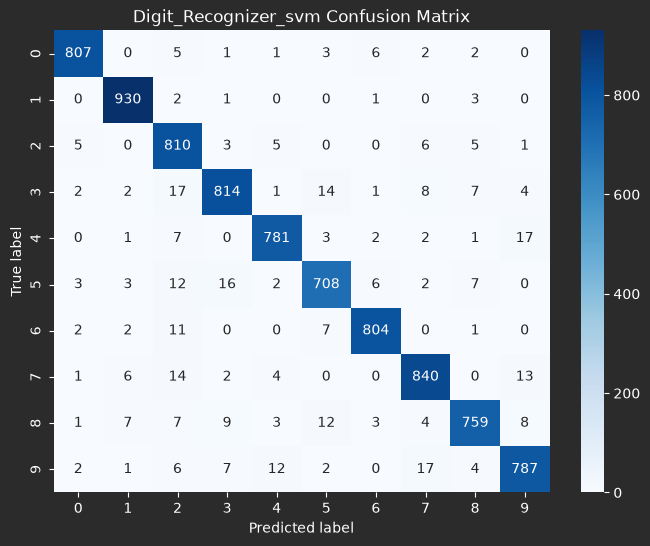


Classification Report - svm
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.98      0.99      0.98       937
           2       0.91      0.97      0.94       835
           3       0.95      0.94      0.94       870
           4       0.97      0.96      0.96       814
           5       0.95      0.93      0.94       759
           6       0.98      0.97      0.97       827
           7       0.95      0.95      0.95       880
           8       0.96      0.93      0.95       813
           9       0.95      0.94      0.94       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400

Saving JSON to: ../Results/Digit_Recognizer_svm_20260814_174212.json

Model: svm
{'accuracy': 0.9571428571428572, 'precision': 0.9574391981706937, 'recall': 0.9571428571428572, 'f1': 0.9571477240391387, 'confusio

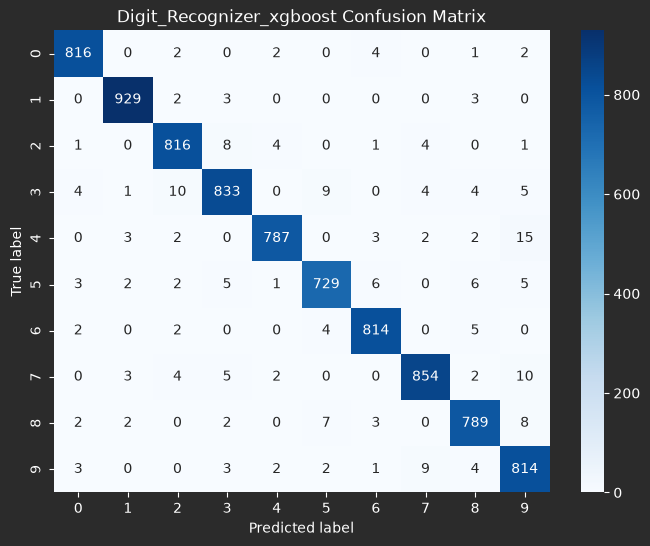


Classification Report - xgboost
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       827
           1       0.99      0.99      0.99       937
           2       0.97      0.98      0.97       835
           3       0.97      0.96      0.96       870
           4       0.99      0.97      0.98       814
           5       0.97      0.96      0.97       759
           6       0.98      0.98      0.98       827
           7       0.98      0.97      0.97       880
           8       0.97      0.97      0.97       813
           9       0.95      0.97      0.96       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400

Saving JSON to: ../Results/Digit_Recognizer_xgboost_20260814_174345.json

Model: xgboost
{'accuracy': 0.9739285714285715, 'precision': 0.9740112081640679, 'recall': 0.9739285714285715, 'f1': 0.973933487154534

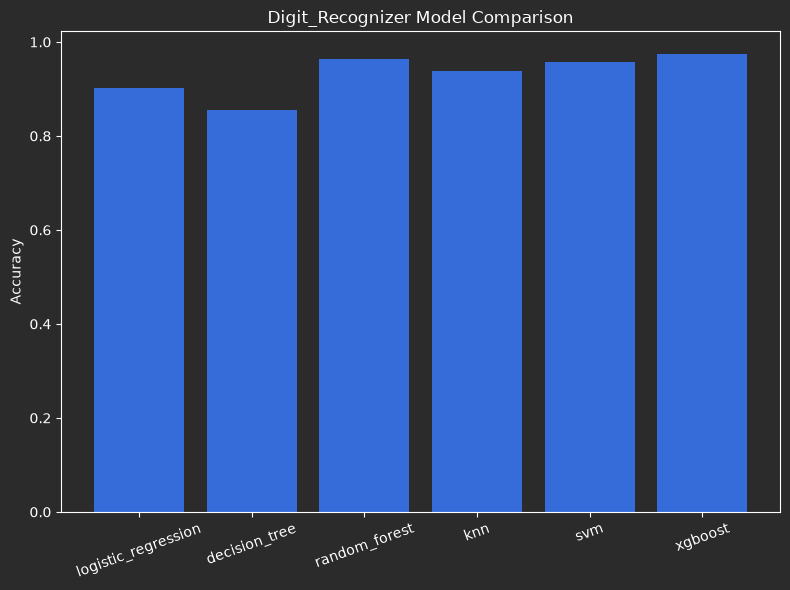

In [13]:
from Models.pipeline import run_pipeline
from utils.logger import save_accuracy_table
from utils.visualization import plot_accuracy_graph

dataset_name = "Digit_Recognizer"

models = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "knn",
    "svm",
    "xgboost"
]

all_results = []

# Use one held-out split to compare classifiers consistently.
for model in models:

    results = run_pipeline(
        X_train,
        X_test,
        X_train_scaled,
        X_test_scaled,
        Y_train,
        Y_test,
        model,
        "Digit_Recognizer"
    )

    all_results.append({
        "Model": model,
        "Accuracy": results["accuracy"],
        "Precision": results["precision"],
        "Recall": results["recall"],
        "F1": results["f1"]
    })

    print(f"\n{'='*50}")
    print(f"Model: {model}")
    print(results)

save_accuracy_table(dataset_name, all_results)
plot_accuracy_graph(dataset_name, all_results)

In [14]:
# Find best model based on accuracy
best_model = max(
    all_results,
    key=lambda x: x["Accuracy"]
)

print("\n" + "=" * 60)
print("BEST PERFORMING MODEL")
print("=" * 60)

print(f"Dataset   : {dataset_name}")
print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall    : {best_model['Recall']:.4f}")
print(f"F1 Score  : {best_model['F1']:.4f}")


BEST PERFORMING MODEL
Dataset   : Digit_Recognizer
Model     : xgboost
Accuracy  : 0.9739
Precision : 0.9740
Recall    : 0.9739
F1 Score  : 0.9739
